In [1]:
import numpy as np
import pandas as pd
import os
import glob
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import metrics
from keras.models import load_model
from keras.preprocessing import image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
import sys

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [2]:
CFG = {
    "train_dir": "data/real-vs-fake/train",
    "test_dir":  "data/real-vs-fake/test",
    "img_size":  (224, 224),
    "batch_size": 32,
    "epochs":    20,
    "seed":      42,
}

In [3]:
print(f"TensorFlow version: {tf.__version__}")
print(f"GPUs available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.15.1
GPUs available: []


In [4]:
import subprocess
result = subprocess.run(['nvcc', '--version'], capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2022 NVIDIA Corporation
Built on Wed_Sep_21_10:41:10_Pacific_Daylight_Time_2022
Cuda compilation tools, release 11.8, V11.8.89
Build cuda_11.8.r11.8/compiler.31833905_0




In [5]:
import tensorflow as tf
tf.sysconfig.get_build_info()

OrderedDict([('is_cuda_build', False),
             ('is_rocm_build', False),
             ('is_tensorrt_build', False),
             ('msvcp_dll_names', 'msvcp140.dll,msvcp140_1.dll')])

In [9]:
import os
os.add_dll_directory(r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8\bin")

import tensorflow as tf
tf.debugging.set_log_device_placement(True)

# Force TF to print all device logs
import logging
logging.getLogger('tensorflow').setLevel(logging.DEBUG)

print(tf.config.list_physical_devices())

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [10]:
import os
os.add_dll_directory(r"C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v11.8\bin")

import tensorflow as tf
print(tf.test.is_built_with_cuda())
print(tf.test.is_gpu_available())

False
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
False


In [12]:
import sys
!{sys.executable} -m pip install tensorflow-gpu==2.15.1

ERROR: Could not find a version that satisfies the requirement tensorflow-gpu==2.15.1 (from versions: 2.12.0)
ERROR: No matching distribution found for tensorflow-gpu==2.15.1


In [4]:
for split in ["train", "test"]:
    split_dir = os.path.join("data/real-vs-fake", split)
    for cls in sorted(os.listdir(split_dir)):
        cls_path = os.path.join(split_dir, cls)
        if os.path.isdir(cls_path):
            count = len(glob.glob(os.path.join(cls_path, "*.jpg")))
            print(f"  [{split}] {cls}: {count} images")

CLASS_NAMES = ["fake", "real"] 

  [train] fake: 19233 images
  [train] real: 18307 images
  [test] fake: 10000 images
  [test] real: 10000 images


In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    CFG["train_dir"],
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    shuffle=True,
    seed=CFG["seed"],
    validation_split=0.2,
    subset="training",
)

Found 37540 files belonging to 2 classes.
Using 30032 files for training.


In [6]:
# import shutil

# # Remove any .ipynb_checkpoints folders inside the data directory
# for root, dirs, files in os.walk("data"):
#     for d in dirs:
#         if d == ".ipynb_checkpoints":
#             path = os.path.join(root, d)
#             shutil.rmtree(path)
#             print(f"Deleted: {path}")

# print("Done — re-run the dataset cells now.")

In [7]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    CFG["train_dir"],
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    shuffle=False,
    seed=CFG["seed"],
    validation_split=0.2,
    subset="validation",
)


Found 37540 files belonging to 2 classes.
Using 7508 files for validation.


In [8]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    CFG["test_dir"],
    labels="inferred",
    label_mode="binary",
    class_names=CLASS_NAMES,
    image_size=CFG["img_size"],
    batch_size=CFG["batch_size"],
    shuffle=False,
)
print(f"\nClasses: {CLASS_NAMES}")

Found 20000 files belonging to 2 classes.

Classes: ['fake', 'real']


In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

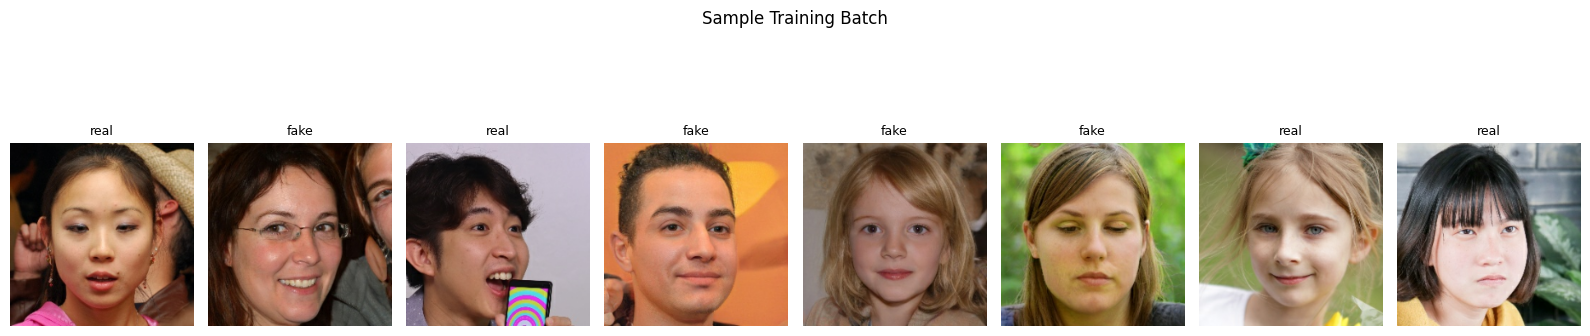

In [10]:
plt.figure(figsize=(16, 4))
for imgs, labels in train_ds.take(1):
    for i in range(8):
        plt.subplot(1, 8, i+1)
        plt.imshow(imgs[i].numpy().astype("uint8"))
        plt.title(CLASS_NAMES[int(labels[i])], fontsize=9)
        plt.axis("off")
plt.suptitle("Sample Training Batch", y=1.02)
plt.tight_layout()
plt.show()

In [11]:
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.2),
], name="augmentation")


preprocess_input = tf.keras.applications.resnet50.preprocess_input

In [12]:
def build_model():
    base = ResNet50(
        weights="imagenet",
        include_top=False,
        input_shape=(*CFG["img_size"], 3),
    )
    base.trainable = False          # freeze backbone to start

    inputs = layers.Input(shape=(*CFG["img_size"], 3))
    x = augment(inputs)             # augmentation only active during training
    x = preprocess_input(x)         # ResNet-specific normalisation
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)  # binary output

    return tf.keras.Model(inputs, outputs)

model = build_model()
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 augmentation (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 tf.__operators__.getitem (  (None, 224, 224, 3)       0         
 SlicingOpLambda)                                                
                                                                 
 tf.nn.bias_add (TFOpLambda  (None, 224, 224, 3)       0         
 )                                                               
                                                                 
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (  (None, 2048)              0     

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
    ]
)

In [14]:
callbacks = [
    EarlyStopping(monitor="val_auc", patience=4, mode="max", restore_best_weights=True),
    ModelCheckpoint("best_model.keras", monitor="val_auc", mode="max", save_best_only=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1),
]

In [15]:
print("\n--- Phase 1: Training head only ---")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=CFG["epochs"],
    callbacks=callbacks,
)


--- Phase 1: Training head only ---
Epoch 1/20
277/939 [=======>......................] - ETA: 22:55 - loss: 0.6077 - accuracy: 0.6884 - auc: 0.7478 - precision: 0.6885 - recall: 0.6503

KeyboardInterrupt: 